In [36]:
# Do not change this cell

import torch
from torch import nn

import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader, SubsetRandomSampler
from torchinfo import summary

import matplotlib.pyplot as plt
from timeit import default_timer as timer

import numpy as np

random_seed = 1
torch.manual_seed(random_seed)
np.random.seed(random_seed)

transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
])

train_transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
])

trainset = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=ToTensor()
)
validationset = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=ToTensor()
)
testset = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=ToTensor()
)
classes = trainset.classes

valid_size = 0.2
train_length = len(trainset)
indices = list(range(len(trainset)))
split = int(np.floor(valid_size * train_length))

np.random.shuffle(indices)

train_idx=indices[split:]
valid_idx=indices[:split]
train_sampler=SubsetRandomSampler(train_idx)
validation_sampler=SubsetRandomSampler(valid_idx)

batch_size = 256
train_loader = DataLoader(trainset, batch_size=batch_size, sampler=train_sampler)
valid_loader = DataLoader(trainset, batch_size=batch_size, sampler=validation_sampler)
test_loader = DataLoader(testset, batch_size=batch_size, shuffle=False)

print(f"Length of train data loader: {len(train_loader)} batches of {batch_size}")
print(f"Length of validation data loader: {len(valid_loader)} batches of {batch_size}")
print(f"Length of test data loader: {len(test_loader)} batches of {batch_size}")

# Check out what is inside the training data loader
train_features_batch, train_label_batch = next(iter(train_loader))
print(train_features_batch.shape, train_label_batch.shape)

Length of train data loader: 188 batches of 256
Length of validation data loader: 47 batches of 256
Length of test data loader: 40 batches of 256
torch.Size([256, 1, 28, 28]) torch.Size([256])


In [37]:
# Do not change this cell
def imshow(img):
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

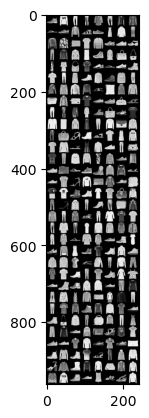

In [38]:
# Do not change this cell
dataiter = iter(test_loader)
images, labels = next(dataiter)
# Show images
imshow(torchvision.utils.make_grid(images))

In [61]:
# TODO: you will design your model here
class ConvModel(nn.Module):
    def __init__(self, input_size, output_size):
        # TODO: complete this method
        super().__init__()

        hidden_size = 32
        self.conv1 = nn.Conv2d(in_channels = input_size, out_channels = hidden_size, 
                              kernel_size = 3, stride = 1, padding = 1)
        
        self.conv2 = nn.Conv2d(in_channels = hidden_size, out_channels = hidden_size, 
                              kernel_size = 3, stride = 1, padding = 1)
        
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size = 2, stride = 2)

        self.fc_1 = nn.Linear(hidden_size * 7 * 7, 128)
        self.fc_2 = nn.Linear(128, output_size)

        self.flatten = nn.Flatten()
        

    def forward(self, x):
        # TODO: complete this method
        x = self.relu(self.conv1(x))
        x = self.pool(x)
        
        x = self.relu(self.conv2(x))
        x = self.pool(x)
        
        x = self.flatten(x)
        
        x = self.relu(self.fc_1(x))
        x = self.fc_2(x)

        return x

In [62]:
def train_step(model, train_loader, loss_fn, optimizer, reg_param, device):
    # TODO: implement one epoch of training
    train_loss, train_acc = 0, 0

    model.to(device)

    for batch, (X, y) in enumerate(train_loader):
        X, y = X.to(device), y.to(device)
        y_pred = model(X)
        loss = loss_fn(y_pred, y) 
        l2_reg = 0
        for i in model.parameters():
            l2_reg += torch.sum(i ** 2)
        loss = loss + reg_param * l2_reg

        train_loss += loss.item()

        correct = torch.eq(y_pred.argmax(dim = 1), y).sum().item() / len(y)
        train_acc += correct

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    train_loss /= len(train_loader)
    train_acc /= len(train_loader)

    return train_loss, train_acc

In [63]:
def evaluation_step(model, data_loader, loss_fn, reg_param, device):
    # TODO: implement evaluation on a data set, data_loader 
    model.eval()
    model.to(device)

    test_loss, test_acc = 0, 0

    with torch.inference_mode():
        for X, y in data_loader:
            X, y = X.to(device), y.to(device)

            y_pred = model(X)
            loss = loss_fn(y_pred, y)
            l2_reg = 0
            for i in model.parameters():
                l2_reg += torch.sum(i ** 2)
            loss = loss + reg_param * l2_reg
                
            test_loss += loss.item()

            correct = torch.eq(y_pred.argmax(dim = 1), y).sum().item() / len(y)
            test_acc += correct

    test_loss /= len(data_loader)
    test_acc /= len(data_loader)

    return test_loss, test_acc
            

In [78]:
# num_epochs = 10
# train_start_time = timer()
# for epoch in range(num_epochs):
#     print(f"Epoch: {epoch}\n-------------")
#     train_step(model, train_data_loader, loss_fn, optimizer, device)
#     test_step(model, test_data_loader, loss_fn, device)

# train_end_time = timer()
# print(f"Train time on {device}: {train_end_time - train_start_time:.3f} seconds")

# you need to keep track of the
# loss and accuracy of your model on the training, validation, and test sets after every
# training epoch.


def train_conv_model(train_loader, valid_loader, test_loader, random_seed):
    # Make device
    device = "cpu"
    if torch.cuda.is_available():
        device = "cuda"
    else:
        if torch.backends.mps.is_available():
            device = "mps"

    torch.manual_seed(random_seed)  # do not change this

    # TODO: write codes to train your model here
    reg_param = 0.001
    num_epochs = 1000

    model = ConvModel(input_size = 1, output_size = 10).to(device)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

    train_l = []
    train_acc = []
    valid_l = []
    valid_acc = []
    test_l = []
    test_acc = []
    
    
    for epoch in range(num_epochs):
        trainl, trainacc = train_step(model, train_loader, loss_fn, optimizer, reg_param, device)

        validl, validacc = evaluation_step(model, valid_loader, loss_fn, reg_param, device)

        testl, testacc = evaluation_step(model, test_loader, loss_fn, reg_param, device)

        train_l.append(trainl)
        train_acc.append(trainacc)
        valid_l.append(validl)
        valid_acc.append(validacc)
        test_l.append(testl)
        test_acc.append(testacc)

    return model, train_l, train_acc, valid_l, valid_acc, test_l, test_acc
    

In [79]:
def plot_accuracy_performance(train_accuracies, valid_accuracies, test_accuracies):
   # TODO: plot accuracy curves, you can reuse your codes from the simple classification task 
    plt.figure(figsize = (8, 6))

    plt.plot(train_accuracies, label = 'Train accuracy')
    plt.plot(valid_accuracies, label = 'Valid accuracy')
    plt.plot(test_accuracies, label = 'Test accuracy')

    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Tratining vs. Valid vs. Test accuracy')
    plt.legend()

In [86]:
def plot_loss_performance(train_losses, valid_losses, test_losses):
    # TODO: plot loss curves, you can reuse your codes from the simple classification task
    plt.figure(figsize = (8, 6))

    plt.plot(train_losses, label = 'Train Loss')
    plt.plot(valid_accuracies, label = 'Valid Loss')
    plt.plot(test_losses, label = 'Test Loss')

    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Train vs. Valid vs. Test loss')
    plt.legend()

In [82]:
# Do not change this cell
random_seed = 1
model, train_losses, train_accuracies, valid_losses, valid_accuracies, test_losses, test_accuracies\
= train_conv_model(train_loader, valid_loader, test_loader, random_seed)

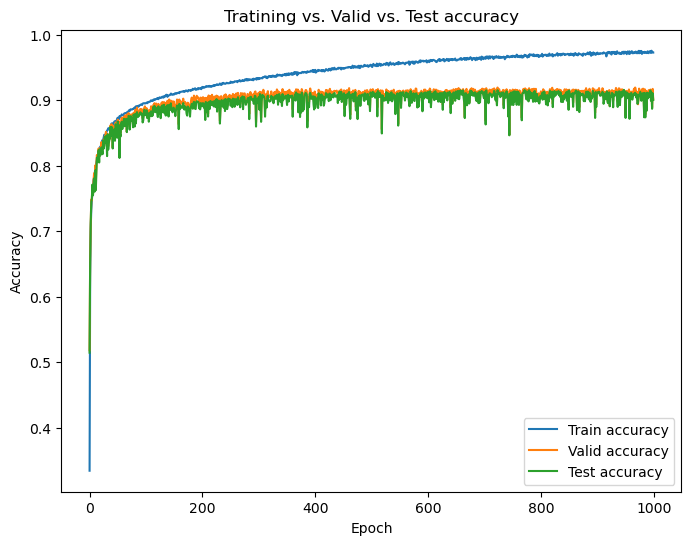

In [83]:
# Do not change this cell
plot_accuracy_performance(train_accuracies, valid_accuracies, test_accuracies)

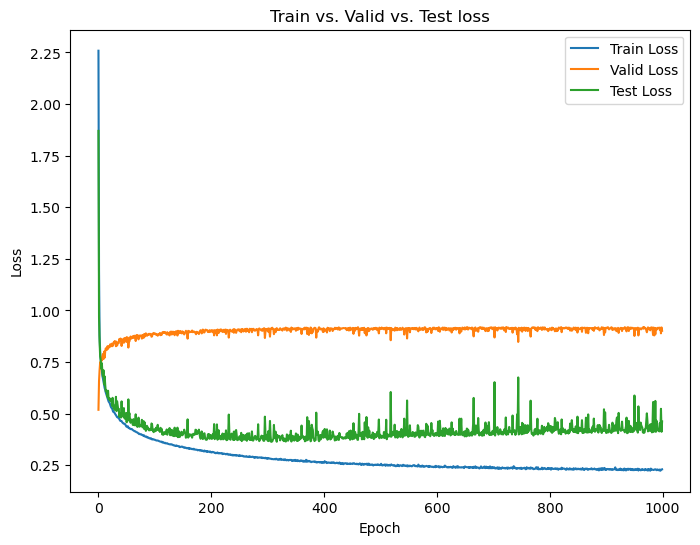

In [87]:
# Do not change this cell
plot_loss_performance(train_losses, valid_losses, test_losses)